In [19]:
import pandas as pd #veriyle çalışmak için kütüphane pd veri işle, plt veri görselleştir

df = pd.read_csv(r"C:\Users\2023\OneDrive\Masaüstü\Sample - Superstore.csv", encoding='latin1') #df=dataframe (tablo) csv dosyasını alıp python a getirdi
print("--- Verinin İlk 5 Satırı ---")
print(df.head()) #ilk 5 satırı getirdi

--- Verinin İlk 5 Satırı ---
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Cat

In [20]:
print("\n--- Veri Bilgisi ---")
print(df.info())  #21 tane colums var , 9994 tane satır(entries ) var


--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null  

In [21]:
df = df.drop(columns=['Row ID']) #Gereksiz sütunları atalım (Row ID bize lazım değil) drop ile attık
df['Order Date'] = pd.to_datetime(df['Order Date']) #Tarih sütununu Python'ın anlayacağı formata çevirelim
df['Month'] = df['Order Date'].dt.month #Analiz kolaylığı için "Ay" ve "Yıl" sütunları ekleyelim
df['Year'] = df['Order Date'].dt.year

In [16]:
print("Eksik Veri Sayısı:")
print(df.isnull().sum())

Eksik Veri Sayısı:
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [23]:
print("\nYeni Sütunlarla İlk 5 Satır:")
print(df[['Order Date', 'Month', 'Year', 'Sales']].head())


Yeni Sütunlarla İlk 5 Satır:
  Order Date  Month  Year     Sales
0 2016-11-08     11  2016  261.9600
1 2016-11-08     11  2016  731.9400
2 2016-06-12      6  2016   14.6200
3 2015-10-11     10  2015  957.5775
4 2015-10-11     10  2015   22.3680


In [61]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("--- TOP 10 BEST-SELLING PRODUCTS ---")
print(top_products) #The highest-selling product is Canon imageCLASS 2200 Advanced Copier, indicating strong demand within the Technology category. Despite potentially lower sales volume, this product generates high revenue due to its high-ticket pricing)
#En çok satış yapan ürün Canon imageCLASS 2200 Advanced Copier olup, Technology kategorisinde güçlü bir talep olduğunu göstermektedir. Bu ürün az satılsa bile yüksek fiyatlı olduğu için toplam satışta önemli bir paya sahiptir.

--- TOP 10 BEST-SELLING PRODUCTS ---
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [60]:
top_categories = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("\n--- CATEGORY-BASED PROFITABILITY ---")
print(top_categories) #The Technology category generates the highest profit, while Furniture performs relatively weaker. This is likely due to lower profit margins in Furniture, driven by higher logistics and storage costs.
#Technology kategorisi en yüksek kârı üretirken, Furniture daha zayıf performans göstermektedir. Bunun nedeni, mobilya kategorisinde yüksek lojistik ve depolama maliyetleri nedeniyle kâr marjlarının daha düşük olması olabilir.


--- CATEGORY-BASED PROFITABILITY ---
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [59]:
monthly_trend = df.groupby('Month')['Sales'].sum()
print("\n--- MONTHLY SALES TOTALS ---")
print(monthly_trend) #Sales peak around month 12, suggesting strong seasonal demand. This increase is likely influenced by year-end campaigns such as Black Friday and holiday shopping periods.
#Satışlar 12. ayda zirve yapmaktadır, bu da güçlü bir mevsimsellik olduğunu gösterir. Bu artış büyük ihtimalle yıl sonu kampanyaları ve Black Friday gibi dönemlerden kaynaklanmaktadır.


--- MONTHLY SALES TOTALS ---
Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


In [58]:
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
print("--- SEGMENT-BASED PROFITABILITY ---")
print(segment_profit)

--- SEGMENT-BASED PROFITABILITY ---
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [57]:
# --- 2. Kargo Süresi Analizi (Shipping Delay) ---
# Kargo süresini hesaplayalım: Ship Date - Order Date
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Ship_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
print("\n---AVERAGE SHIPPING TIME (DAYS) ---")
print(df['Ship_Duration'].mean())


---AVERAGE SHIPPING TIME (DAYS) ---
3.958174904942966


In [55]:
# --- 3. Kargo Süresinin Satışa Etkisi (Kategori Bazlı) ---
ship_effect = df.groupby('Category')['Ship_Duration'].mean()
print("\n--- AVERAGE SHIPPING TIME BY CATEGORY ---")
print(ship_effect)


--- AVERAGE SHIPPING TIME BY CATEGORY ---
Category
Furniture          3.917020
Office Supplies    3.983405
Technology         3.923119
Name: Ship_Duration, dtype: float64


In [56]:
# --- 5. Alt Kategoride En Çok Satan Ürünler (Pivot Table) ---
# Bu biraz daha ileri seviye bir teknik:
sub_cat_sales = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()
print("\n--- CATEGORY & SUB-CATEGORY SALES ---")
print(sub_cat_sales)


--- CATEGORY & SUB-CATEGORY SALES ---
           Category Sub-Category        Sales
0         Furniture    Bookcases  114879.9963
1         Furniture       Chairs  328449.1030
2         Furniture  Furnishings   91705.1640
3         Furniture       Tables  206965.5320
4   Office Supplies   Appliances  107532.1610
5   Office Supplies          Art   27118.7920
6   Office Supplies      Binders  203412.7330
7   Office Supplies    Envelopes   16476.4020
8   Office Supplies    Fasteners    3024.2800
9   Office Supplies       Labels   12486.3120
10  Office Supplies        Paper   78479.2060
11  Office Supplies      Storage  223843.6080
12  Office Supplies     Supplies   46673.5380
13       Technology  Accessories  167380.3180
14       Technology      Copiers  149528.0300
15       Technology     Machines  189238.6310
16       Technology       Phones  330007.0540


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
sns.set_theme(style="whitegrid")

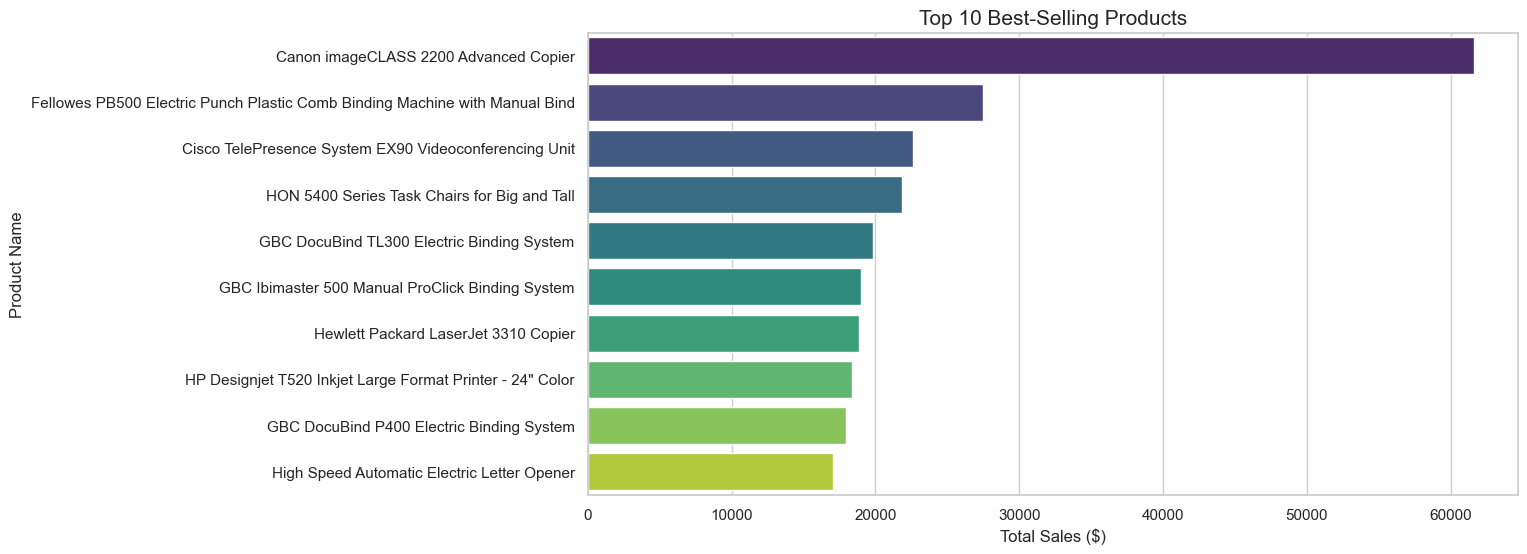

In [54]:
#1. GRAFİK: En Çok Satan 10 Ürün (Bar Chart)
plt.figure(figsize=(12, 6))

# y eksenindeki veriyi aynı zamanda 'hue' (renk) olarak ata ve legend'ı kapat
sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    hue=top_products.index, 
    palette="viridis", 
    legend=False
)

plt.title("Top 10 Best-Selling Products", fontsize=15)
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")
plt.show()

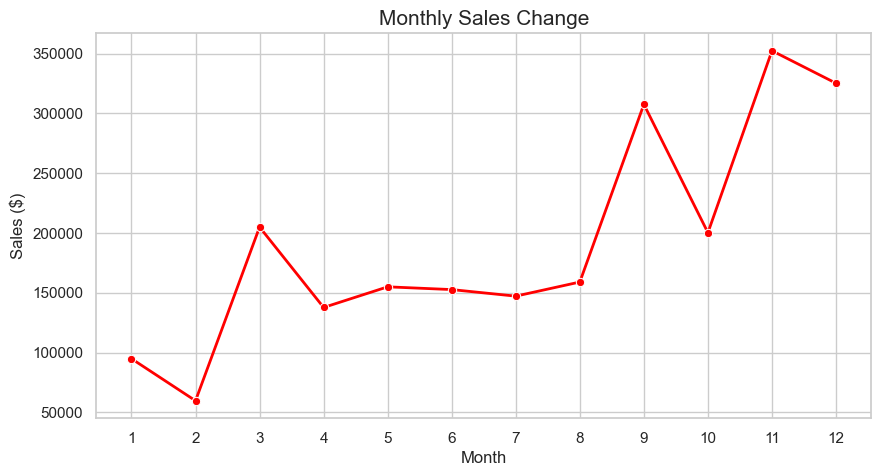

In [53]:
#2. GRAFİK: Aylık Satış Trendi (Line Chart)
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='red', linewidth=2)
plt.title("Monthly Sales Change", fontsize=15)
plt.xticks(range(1, 13)) # 1'den 12'ye kadar ayları göster
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.show()

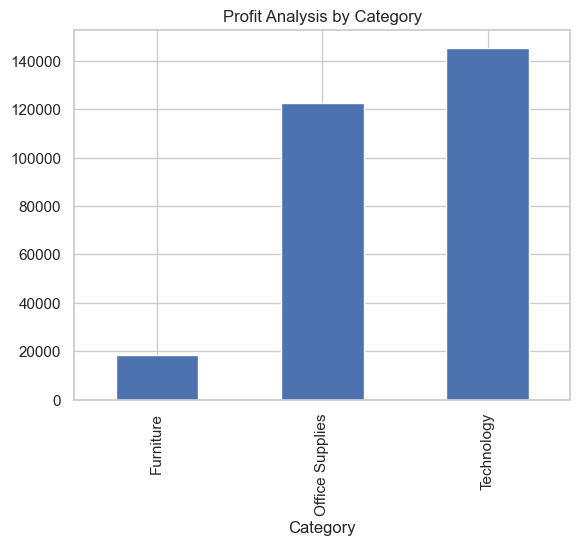

In [45]:
#3. GRAFİK: Katetogi Karlılık Analizi (Line Chart)
profit_category = df.groupby('Category')['Profit'].sum()
profit_category.plot(kind='bar', title="Profit Analysis by Category")
plt.show()

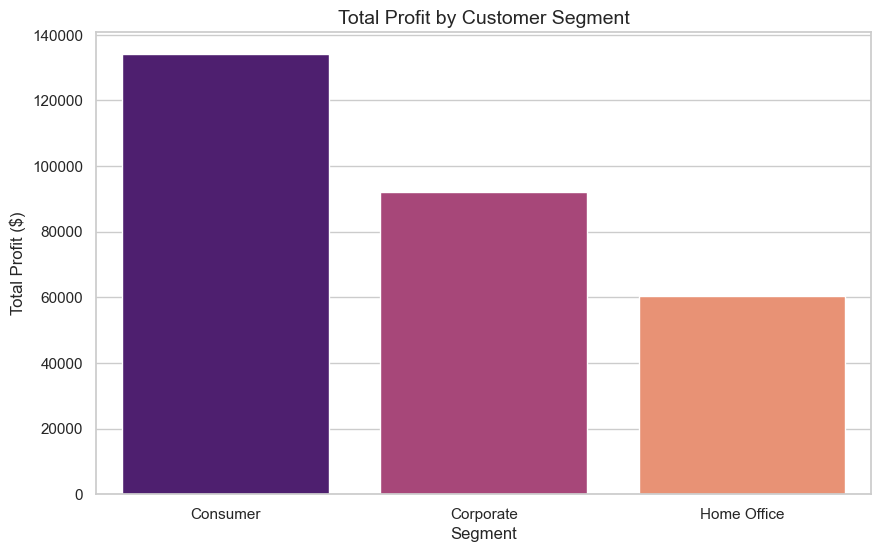

In [52]:
# 4. GRAFİK: Müşteri Segmentine Göre Karlılık (Hangi grup daha bereketli?)
segment_analysis = df.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'})
plt.figure(figsize=(10, 6))
sns.barplot(
    x=segment_analysis.index, 
    y='Profit', 
    data=segment_analysis, 
    palette="magma", 
    hue=segment_analysis.index, 
    legend=False
)
plt.title("Total Profit by Customer Segment", fontsize=14)
plt.ylabel("Total Profit ($)")
plt.show()

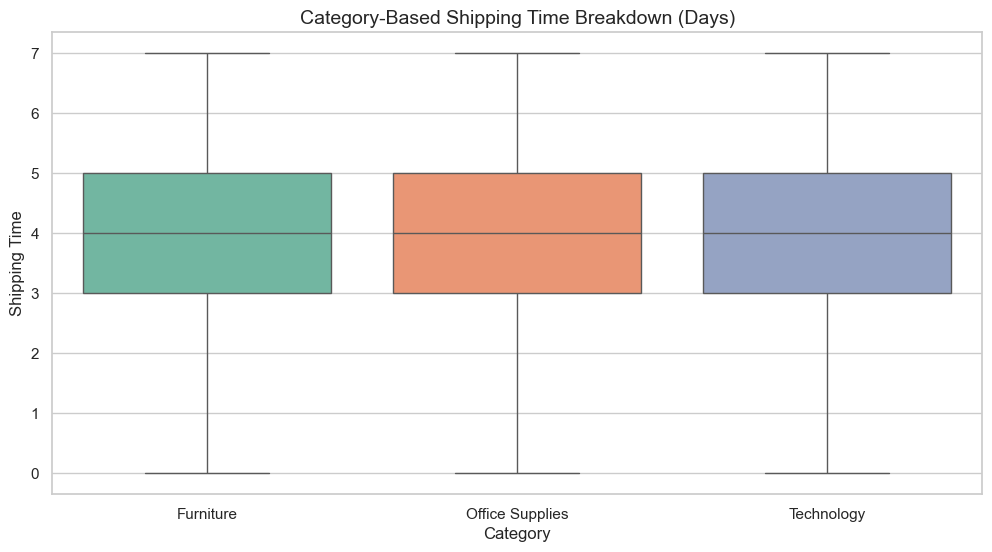

In [51]:
# 5. GRAFİK: Kargo Süresinin Kategori Bazlı Dağılımı (Kutu Grafiği - Box Plot)
# Bu grafik, kargo sürelerindeki sapmaları (gecikmeleri) en iyi gösteren grafiktir.
plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Ship_Duration', data=df, palette="Set2", hue='Category', legend=False)
plt.title("Category-Based Shipping Time Breakdown (Days)", fontsize=14)
plt.ylabel("Shipping Time")
plt.show()

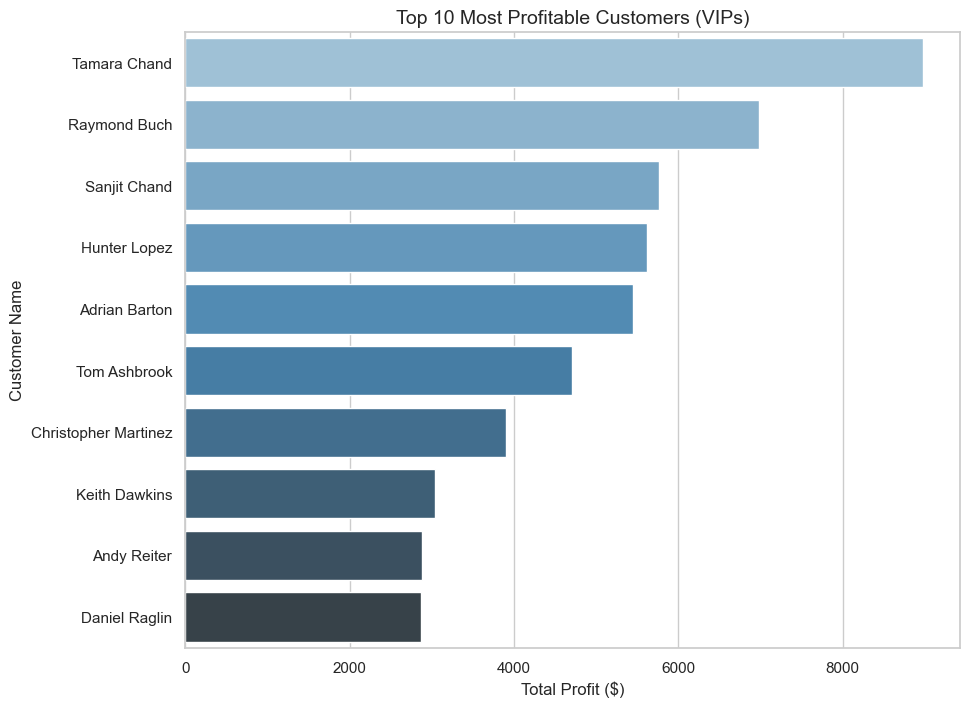

In [63]:
# 6. GRAFİK: En Karlı 10 Müşteri (Yatay Bar)
top_10_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 8))
sns.barplot(
    x=top_10_customers.values, 
    y=top_10_customers.index, 
    palette="Blues_d", 
    hue=top_10_customers.index, 
    legend=False
)
plt.title("Top 10 Most Profitable Customers (VIPs)", fontsize=14)
plt.xlabel("Total Profit ($)")
plt.ylabel("Customer Name")
plt.show()